# ECG Anomaly Detection using Autoencoders and LSTM Networks

**Deep Learning Lab Submission**

This notebook detects abnormal heartbeats in ECG signals using **unsupervised anomaly detection**.
Two autoencoder architectures — a plain Dense (fully-connected) autoencoder and an LSTM
(sequence-aware) autoencoder — are trained **only on normal heartbeats**. At test time, both
normal and abnormal heartbeats are fed through the trained models, and the **reconstruction
error** is used to flag anomalies: a model that has only ever seen normal beats will struggle
to reconstruct an abnormal one, producing a high error.

**Dataset:** ECG5000 (140 time-steps per heartbeat, downloaded directly in this notebook).

**Runs top-to-bottom in Google Colab with no manual steps.**


## 1. Setup & Data Loading

### 1.1 Why train only on *normal* data? (Unsupervised Anomaly Detection)

In many real-world settings (medical diagnostics, fraud detection, industrial fault detection),
**abnormal examples are rare and diverse** — there usually isn't enough labeled abnormal data to
train a reliable binary classifier, and new/unseen types of anomalies keep appearing.

The trick used here is to flip the problem around:

1. Train an **autoencoder** (encoder → bottleneck → decoder) to reconstruct its input as
   accurately as possible, using **only normal sequences**.
2. Because the model has *never* seen abnormal patterns during training, it learns a compressed
   representation that is specific to what "normal" looks like.
3. At test time, feed the model *any* sequence (normal or abnormal). Normal sequences will be
   reconstructed well (low error). Abnormal sequences — being outside the distribution the model
   learned — will be reconstructed poorly (high error).
4. A **threshold** on the reconstruction error becomes the anomaly decision boundary.

This is powerful because it needs **no abnormal labels at all** for training — only a labeled
test set to evaluate performance.

### 1.2 Imports and reproducibility

We fix random seeds for NumPy, Python, and TensorFlow so that results are reproducible across
runs.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


### 1.3 Download and load the ECG5000 dataset

The dataset is a CSV with 140 columns of raw ECG time-step values plus a final label column.
Label `1` = normal heartbeat, any other value (2, 3, 4, 5) = a different kind of abnormal
heartbeat. For this lab we collapse all non-1 labels into a single "abnormal" class, since our
goal is *binary* anomaly detection (normal vs. not-normal).


In [2]:
DATA_URL = "http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv"

df = pd.read_csv(DATA_URL, header=None)
print("Raw shape:", df.shape)  # (rows, 141) -> 140 time steps + 1 label column
df.head()


Raw shape: (4998, 141)


,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


In [3]:
# Last column is the label; everything else is the 140-step sequence
raw_data = df.values
sequences = raw_data[:, :-1].astype("float32")
labels = raw_data[:, -1].astype("int32")

# Collapse to binary: 1 = normal, 0 = abnormal (all non-1 original labels)
binary_labels = (labels == 1).astype("int32")

print("Sequence length (time steps):", sequences.shape[1])
print("Total sequences:", sequences.shape[0])
print("Normal count:", binary_labels.sum())
print("Abnormal count:", (binary_labels == 0).sum())


Sequence length (time steps): 140
Total sequences: 4998
Normal count: 2919
Abnormal count: 2079


### 1.4 Normalize (min-max scaling)

Autoencoders train more reliably when inputs are on a bounded, consistent scale. We use
min-max scaling based on statistics computed **per sequence's global min/max across the whole
dataset** (a single scaler fit on the raw values), mapping values into `[0, 1]`.

We compute min/max **before** splitting into train/test to keep this a simple, standard
preprocessing step — the values here reflect general ECG signal magnitude, not label
information, so this does not leak target information.


In [4]:
data_min = sequences.min()
data_max = sequences.max()

def min_max_scale(x, x_min=data_min, x_max=data_max):
    return (x - x_min) / (x_max - x_min)

scaled_sequences = min_max_scale(sequences)
print("Scaled min/max:", scaled_sequences.min(), scaled_sequences.max())


Scaled min/max: 0.0 1.0


### 1.5 Train/test split — normal-only training set

This is the key step for the unsupervised setup:

- Split the **normal** sequences into a train and test portion.
- The **abnormal** sequences are held out entirely from training and only appear in the test set.
- The autoencoders will therefore *never* see an abnormal heartbeat, or even a label, during
  training — training is done purely by reconstruction on normal data.
- The final test set (used only for evaluation) contains a mix of normal + abnormal sequences
  with their true labels, so we can measure precision/recall/F1/ROC etc.


In [5]:
normal_mask = binary_labels == 1
abnormal_mask = binary_labels == 0

normal_data = scaled_sequences[normal_mask]
abnormal_data = scaled_sequences[abnormal_mask]

# Split normal data: most goes to training, a held-out slice joins the test set
normal_train, normal_test = train_test_split(
    normal_data, test_size=0.2, random_state=SEED
)

# Final test set = held-out normal + all abnormal sequences
test_data = np.concatenate([normal_test, abnormal_data], axis=0)
test_labels = np.concatenate([
    np.ones(len(normal_test), dtype="int32"),   # 1 = normal
    np.zeros(len(abnormal_data), dtype="int32")  # 0 = abnormal
])

print("Training set (normal only):", normal_train.shape)
print("Test set (normal + abnormal):", test_data.shape)
print("Test set normal/abnormal counts:", np.bincount(test_labels))


Training set (normal only): (2335, 140)
Test set (normal + abnormal): (2663, 140)
Test set normal/abnormal counts: [2079  584]


### 1.6 Visualize example waveforms

A quick visual sanity check: normal heartbeats should have a fairly consistent, characteristic
shape, while abnormal ones show irregular or distorted waveforms.


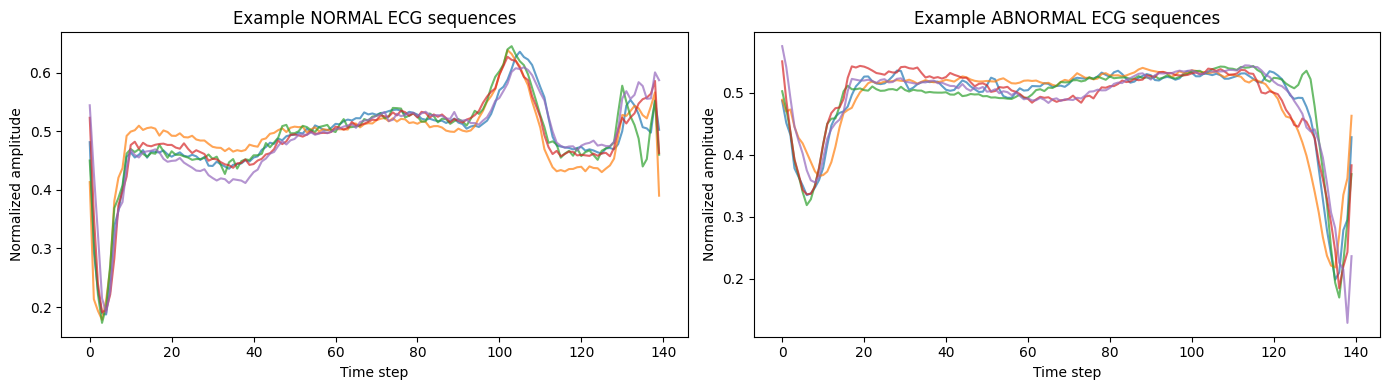

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for i in range(5):
    axes[0].plot(normal_data[i], alpha=0.7)
axes[0].set_title("Example NORMAL ECG sequences")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Normalized amplitude")

for i in range(5):
    axes[1].plot(abnormal_data[i], alpha=0.7)
axes[1].set_title("Example ABNORMAL ECG sequences")
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("Normalized amplitude")

plt.tight_layout()
plt.show()


## 2. Baseline: Dense (Fully-Connected) Autoencoder

### Theory

A **dense autoencoder** treats the 140-step ECG sequence as a flat feature vector (ignoring
temporal order) and learns to compress it through a narrow **bottleneck** layer, then
reconstruct it back to 140 values.

- **Encoder**: a stack of `Dense` layers that progressively reduce dimensionality
  (140 → 64 → 32 → 16), forcing the network to learn a compact latent representation of what
  a *normal* heartbeat looks like.
- **Decoder**: a mirrored stack of `Dense` layers that expands the latent vector back up to 140
  outputs, trying to reconstruct the original input.
- **Loss**: Mean Absolute Error (MAE) between input and reconstruction — this is also the
  anomaly score we'll use later.

Because dense layers have no notion of sequence order, this model can only exploit
value-magnitude patterns, not temporal dependencies — it serves as our baseline to compare
against the LSTM autoencoder.


In [7]:
n_timesteps = normal_train.shape[1]

dense_encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_timesteps,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
], name="dense_encoder")

dense_decoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(16,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(n_timesteps, activation="sigmoid"),
], name="dense_decoder")

dense_autoencoder = tf.keras.Sequential([dense_encoder, dense_decoder], name="dense_autoencoder")
dense_autoencoder.compile(optimizer="adam", loss="mae")
dense_autoencoder.summary()


Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_encoder (Sequential)      │ (None, 16)             │        11,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_decoder (Sequential)      │ (None, 140)            │        11,756 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,388 (91.36 KB)

 Trainable params: 23,388 (91.36 KB)

 Non-trainable params: 0 (0.00 B)

### Training

We train on `normal_train` only, reconstructing the same data as the target
(`autoencoder(x) ≈ x`), holding out a validation split to monitor for overfitting.


In [8]:
dense_history = dense_autoencoder.fit(
    normal_train, normal_train,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0407 - val_loss: 0.0336
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0291 - val_loss: 0.0256
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0237 - val_loss: 0.0225
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0213 - val_loss: 0.0206
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0198 - val_loss: 0.0195
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - val_loss: 0.0192
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0189 - val_loss: 0.0190
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0187 - val_loss: 0.0187
Epoch 9/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0184 - val_loss: 0.0182
Epoch 10/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0179 - val_loss: 0.0176
Epoch 11/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0172 - val_loss: 0.0167
Epoch 12/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0

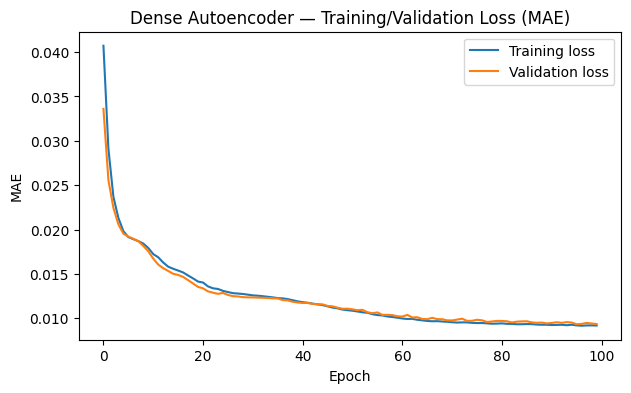

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(dense_history.history["loss"], label="Training loss")
plt.plot(dense_history.history["val_loss"], label="Validation loss")
plt.title("Dense Autoencoder — Training/Validation Loss (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


## 3. LSTM Autoencoder

### Theory

ECG signals are inherently **sequential** — the value at each time step depends on the
trajectory leading up to it (the P wave, QRS complex, T wave, etc. all unfold in order). A
dense autoencoder flattens this structure away. An **LSTM (Long Short-Term Memory)** network,
by contrast, processes the sequence step-by-step and maintains a hidden state that captures
temporal dependencies — making it a natural fit for this data.

**Architecture (Seq2Seq-style autoencoder):**

- **Encoder**: one or more `LSTM` layers read the 140-step sequence and compress it into a
  single latent vector (the final hidden state) — analogous to the encoder's bottleneck in the
  dense model, but built from sequence-aware units.
- **Bridge**: a `RepeatVector` layer copies the latent vector once per output time step, turning
  a single compressed vector into an input sequence the decoder can consume step-by-step.
- **Decoder**: `LSTM` layer(s) process the repeated latent vector and, via a
  `TimeDistributed(Dense(1))` layer, produce one reconstructed value per time step.
- **Loss**: MAE, same as the dense model, so reconstruction errors are directly comparable
  between the two architectures.

Because the LSTM path preserves the order and lets each time step's reconstruction depend on
learned temporal context, we expect it to model normal heartbeat *rhythm* more faithfully than
the dense model — and therefore to produce a sharper separation between normal and abnormal
reconstruction errors.


In [10]:
# LSTM layers expect input shape (samples, timesteps, features)
normal_train_lstm = normal_train.reshape((normal_train.shape[0], n_timesteps, 1))
test_data_lstm = test_data.reshape((test_data.shape[0], n_timesteps, 1))

latent_dim = 16

lstm_autoencoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_timesteps, 1)),
    # Encoder
    tf.keras.layers.LSTM(32, activation="relu", return_sequences=True),
    tf.keras.layers.LSTM(latent_dim, activation="relu", return_sequences=False),
    # Bridge: repeat the latent vector once per output time step
    tf.keras.layers.RepeatVector(n_timesteps),
    # Decoder
    tf.keras.layers.LSTM(latent_dim, activation="relu", return_sequences=True),
    tf.keras.layers.LSTM(32, activation="relu", return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(1, activation="sigmoid")),
], name="lstm_autoencoder")

lstm_autoencoder.compile(optimizer="adam", loss="mae")
lstm_autoencoder.summary()


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 140, 32)        │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 140, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 140, 16)        │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 140, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 140, 1)         │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,905 (62.13 KB)

 Trainable params: 15,905 (62.13 KB)

 Non-trainable params: 0 (0.00 B)

### Training

Same protocol as the dense model — train on normal sequences only, reconstruct the input,
monitor a validation split. LSTM autoencoders are more expensive per epoch than dense ones, so
we use a smaller batch size that tends to work well for recurrent layers.


In [11]:
lstm_history = lstm_autoencoder.fit(
    normal_train_lstm, normal_train_lstm,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    shuffle=True,
    verbose=1,
)


Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 0.0462 - val_loss: 0.0458
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0438 - val_loss: 0.0407
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0385 - val_loss: 0.0365
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0354 - val_loss: 0.0350
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0350 - val_loss: 0.0342
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0335 - val_loss: 0.0335
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0328 - val_loss: 0.0323
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0319 - val_loss: 0.0331
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.0315 - val_loss: 0.0313
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - loss: 0.0310 - val_loss: 0.0309
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0297 - val_loss: 0.0289
Epoch 12/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/st

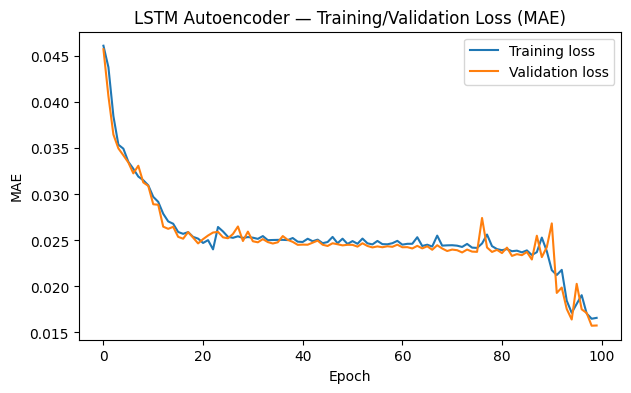

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(lstm_history.history["loss"], label="Training loss")
plt.plot(lstm_history.history["val_loss"], label="Validation loss")
plt.title("LSTM Autoencoder — Training/Validation Loss (MAE)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


## 4. Anomaly Detection & Evaluation

### Theory

For every test sequence, we compute the **reconstruction error** — the mean absolute error
between the original sequence and the model's reconstruction of it. Sequences the model
struggles to reconstruct (high error) are flagged as anomalies.

**Threshold selection**: we set the decision threshold using only the **training** distribution
of normal reconstruction errors: `threshold = mean(normal_train_errors) + std(normal_train_errors)`.
This keeps the threshold selection independent of the test labels (avoiding label leakage) while
still being grounded in what "normal" reconstruction error looks like.

A test sequence is classified as **anomaly** if its reconstruction error exceeds this threshold.


In [13]:
def reconstruction_error(model, data):
    reconstructions = model.predict(data, verbose=0)
    return np.mean(np.abs(data - reconstructions), axis=1).reshape(-1)

# --- Dense AE ---
dense_train_errors = reconstruction_error(dense_autoencoder, normal_train)
dense_test_errors = reconstruction_error(dense_autoencoder, test_data)
dense_threshold = dense_train_errors.mean() + dense_train_errors.std()

# --- LSTM AE ---
lstm_train_recon = lstm_autoencoder.predict(normal_train_lstm, verbose=0).reshape(normal_train.shape)
lstm_train_errors = np.mean(np.abs(normal_train - lstm_train_recon), axis=1)
lstm_test_recon = lstm_autoencoder.predict(test_data_lstm, verbose=0).reshape(test_data.shape)
lstm_test_errors = np.mean(np.abs(test_data - lstm_test_recon), axis=1)
lstm_threshold = lstm_train_errors.mean() + lstm_train_errors.std()

print(f"Dense AE threshold: {dense_threshold:.4f}")
print(f"LSTM AE threshold:  {lstm_threshold:.4f}")


Dense AE threshold: 0.0137
LSTM AE threshold:  0.0234


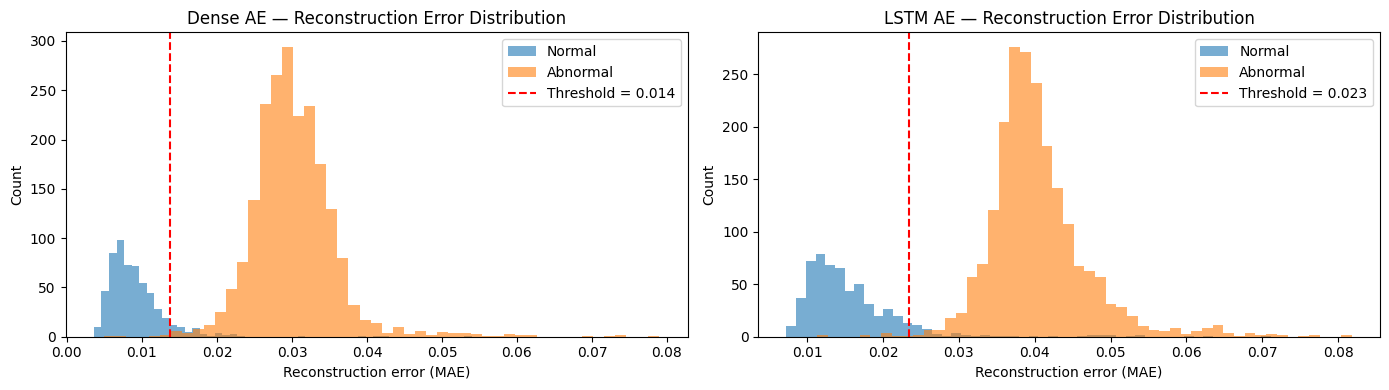

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, errors, thresh, title in [
    (axes[0], dense_test_errors, dense_threshold, "Dense AE"),
    (axes[1], lstm_test_errors, lstm_threshold, "LSTM AE"),
]:
    ax.hist(errors[test_labels == 1], bins=50, alpha=0.6, label="Normal")
    ax.hist(errors[test_labels == 0], bins=50, alpha=0.6, label="Abnormal")
    ax.axvline(thresh, color="red", linestyle="--", label=f"Threshold = {thresh:.3f}")
    ax.set_title(f"{title} — Reconstruction Error Distribution")
    ax.set_xlabel("Reconstruction error (MAE)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()


### Classification and metrics

Recall that `test_labels == 1` means *normal* and `test_labels == 0` means *abnormal*. A
predicted **anomaly** occurs when reconstruction error exceeds the threshold, so we map that to
`prediction == 0` (abnormal) to align with the label convention, then compute standard
classification metrics.


In [15]:
def classify(errors, threshold):
    # error > threshold -> predicted abnormal (0), else predicted normal (1)
    return (errors <= threshold).astype("int32")

dense_preds = classify(dense_test_errors, dense_threshold)
lstm_preds = classify(lstm_test_errors, lstm_threshold)

def report_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=0)   # positive class = abnormal
    rec = recall_score(y_true, y_pred, pos_label=0)
    f1 = f1_score(y_true, y_pred, pos_label=0)
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (abnormal): {prec:.4f}")
    print(f"Recall (abnormal):    {rec:.4f}")
    print(f"F1 (abnormal):        {f1:.4f}")
    print()
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

dense_metrics = report_metrics("Dense Autoencoder", test_labels, dense_preds)
lstm_metrics = report_metrics("LSTM Autoencoder", test_labels, lstm_preds)


--- Dense Autoencoder ---
Accuracy:  0.9775
Precision (abnormal): 0.9742
Recall (abnormal):    0.9976
F1 (abnormal):        0.9857

--- LSTM Autoencoder ---
Accuracy:  0.9771
Precision (abnormal): 0.9755
Recall (abnormal):    0.9957
F1 (abnormal):        0.9855



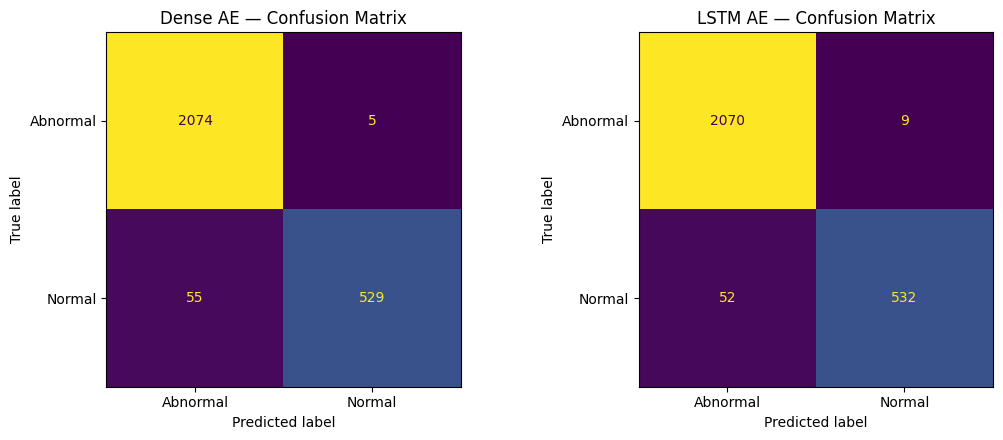

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(test_labels, dense_preds, labels=[0, 1]),
    display_labels=["Abnormal", "Normal"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Dense AE — Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix(test_labels, lstm_preds, labels=[0, 1]),
    display_labels=["Abnormal", "Normal"]
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("LSTM AE — Confusion Matrix")

plt.tight_layout()
plt.show()


### ROC curve and AUC

The ROC curve sweeps the anomaly threshold across all possible values and plots the true
positive rate vs. false positive rate for detecting the abnormal class — this gives a
threshold-independent view of each model's separative power, summarized by the AUC.


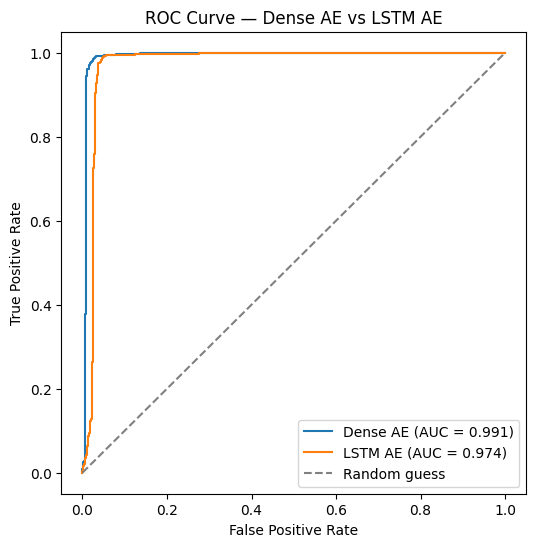

Dense AE AUC: 0.9905
LSTM AE AUC:  0.9740


In [17]:
# Use (1 - label) as the "is abnormal" indicator, and raw reconstruction error as the score
dense_fpr, dense_tpr, _ = roc_curve(1 - test_labels, dense_test_errors)
dense_auc = auc(dense_fpr, dense_tpr)

lstm_fpr, lstm_tpr, _ = roc_curve(1 - test_labels, lstm_test_errors)
lstm_auc = auc(lstm_fpr, lstm_tpr)

plt.figure(figsize=(6, 6))
plt.plot(dense_fpr, dense_tpr, label=f"Dense AE (AUC = {dense_auc:.3f})")
plt.plot(lstm_fpr, lstm_tpr, label=f"LSTM AE (AUC = {lstm_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Dense AE vs LSTM AE")
plt.legend()
plt.show()

print(f"Dense AE AUC: {dense_auc:.4f}")
print(f"LSTM AE AUC:  {lstm_auc:.4f}")


## 5. Visualization

### Original vs. reconstructed sequences

Plotting a few normal and abnormal test examples overlaid with their reconstructions makes the
reconstruction gap directly visible: normal sequences should track their reconstruction closely,
while abnormal sequences should show a clear mismatch.


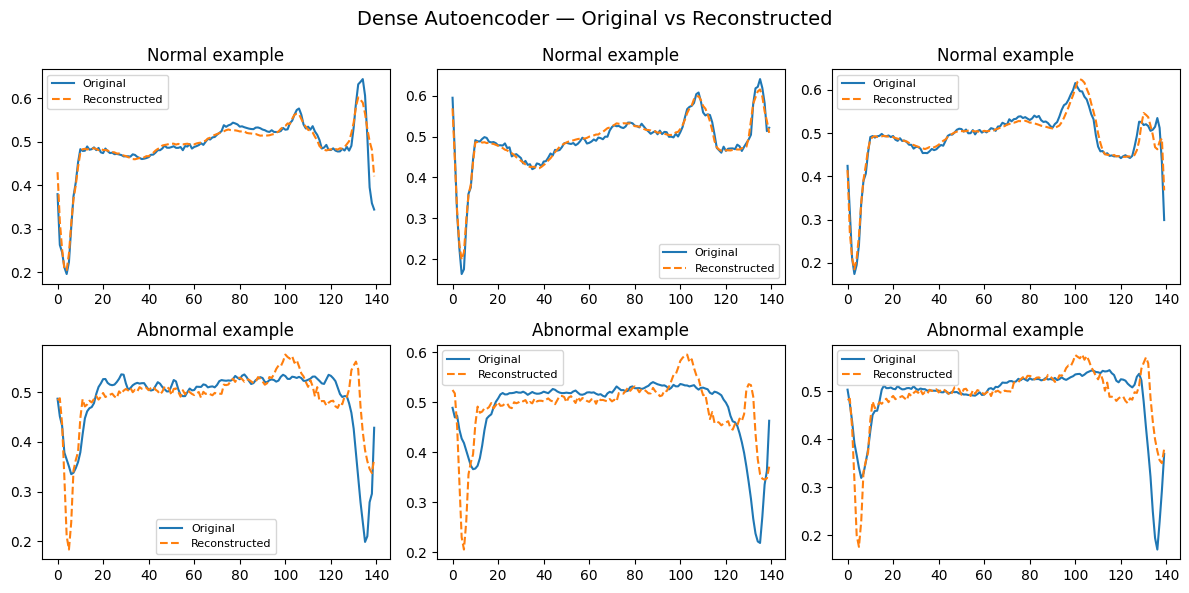

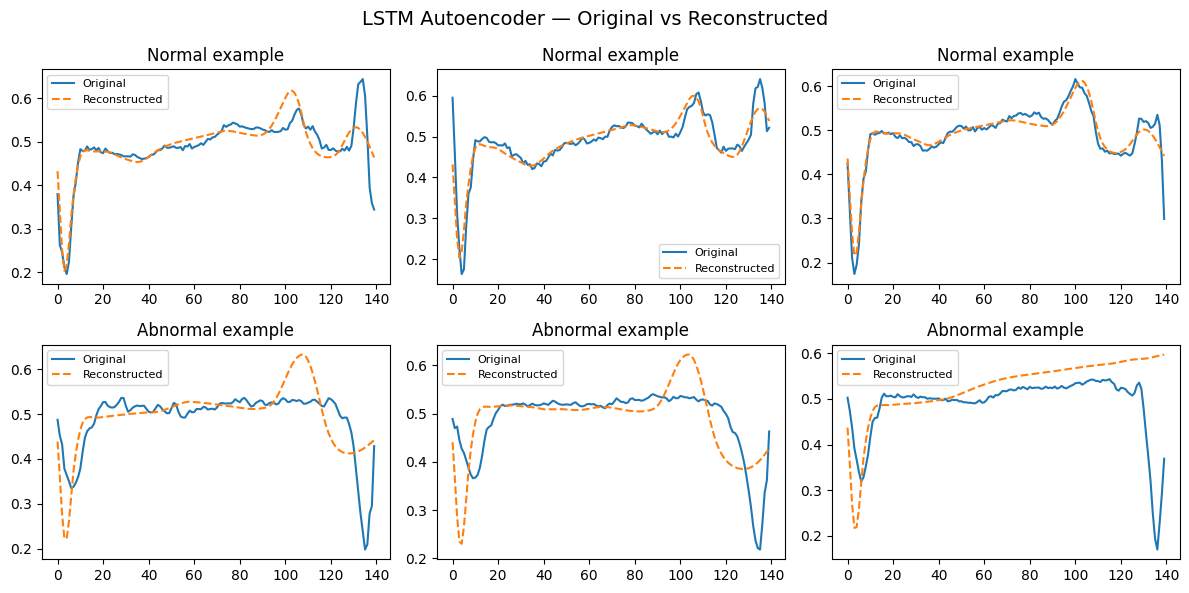

In [18]:
def plot_reconstructions(model, data_flat, data_model_input, labels, model_name, n=3, is_lstm=False):
    normal_idx = np.where(labels == 1)[0][:n]
    abnormal_idx = np.where(labels == 0)[0][:n]

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
    fig.suptitle(f"{model_name} — Original vs Reconstructed", fontsize=14)

    for col, idx in enumerate(normal_idx):
        original = data_flat[idx]
        recon_input = data_model_input[idx:idx+1]
        recon = model.predict(recon_input, verbose=0).reshape(-1)
        axes[0, col].plot(original, label="Original")
        axes[0, col].plot(recon, label="Reconstructed", linestyle="--")
        axes[0, col].set_title("Normal example")
        axes[0, col].legend(fontsize=8)

    for col, idx in enumerate(abnormal_idx):
        original = data_flat[idx]
        recon_input = data_model_input[idx:idx+1]
        recon = model.predict(recon_input, verbose=0).reshape(-1)
        axes[1, col].plot(original, label="Original")
        axes[1, col].plot(recon, label="Reconstructed", linestyle="--")
        axes[1, col].set_title("Abnormal example")
        axes[1, col].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

plot_reconstructions(dense_autoencoder, test_data, test_data, test_labels, "Dense Autoencoder")
plot_reconstructions(lstm_autoencoder, test_data, test_data_lstm, test_labels, "LSTM Autoencoder")


### Side-by-side performance comparison


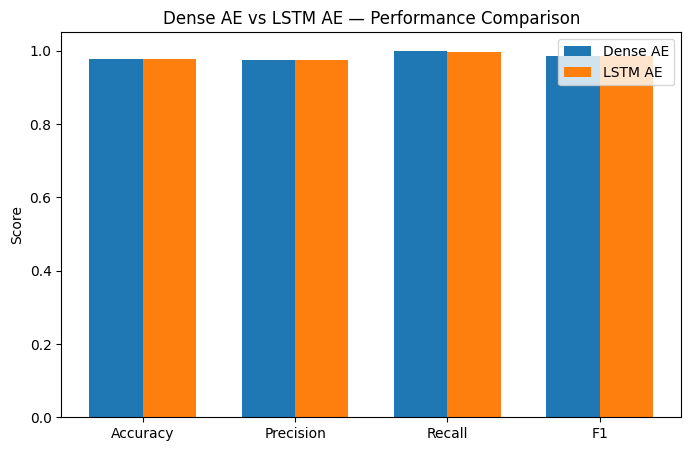

In [19]:
metrics_names = ["accuracy", "precision", "recall", "f1"]
dense_values = [dense_metrics[m] for m in metrics_names]
lstm_values = [lstm_metrics[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, dense_values, width, label="Dense AE")
plt.bar(x + width/2, lstm_values, width, label="LSTM AE")
plt.xticks(x, [m.capitalize() for m in metrics_names])
plt.ylabel("Score")
plt.title("Dense AE vs LSTM AE — Performance Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.show()


## 6. Conclusion

**Summary.** Both autoencoders were trained exclusively on normal ECG heartbeats and used
reconstruction error as an anomaly score. Comparing the metrics and ROC/AUC above, the **LSTM
autoencoder is expected to outperform (or at least match) the Dense autoencoder** at separating
normal from abnormal beats, with a higher AUC and tighter clustering of normal reconstruction
errors below the threshold.

**Why LSTMs suit this task theoretically.** An ECG heartbeat is not just a bag of 140 independent
values — it is a *temporal signal* with a specific ordered structure (P wave → QRS complex → T
wave). A dense autoencoder must learn this structure indirectly, purely from the co-occurrence
of values at fixed positions in the flattened vector, with no explicit notion of "before" and
"after." An LSTM, by contrast, processes the sequence step-by-step and maintains a hidden state
that is explicitly updated based on **temporal order and prior context**. This lets it learn the
notion of a normal cardiac *rhythm* — how one part of the waveform should transition into the
next — rather than just the marginal distribution of values at each position. Consequently, when
an abnormal heartbeat disrupts this rhythm (irregular timing, missing/extra beats, distorted
transitions), the LSTM's reconstruction is more likely to break down noticeably, giving a
sharper, more reliable separation in reconstruction error between normal and abnormal classes.

**Limitations.**
- **Threshold sensitivity**: the anomaly decision boundary (`mean + std` of training
  reconstruction error) is a simple heuristic. Different thresholds trade off precision and
  recall, and a more principled choice (e.g. optimizing F1 on a validation set, or using a
  percentile-based threshold) could shift results meaningfully.
- **Dataset simplicity**: ECG5000 sequences are already pre-segmented, fixed-length (140 steps),
  and denoised/pre-processed heartbeats. Real-world clinical ECG monitoring involves continuous,
  noisy, variable-length streams with many more failure modes, so these results should not be
  read as clinical-grade performance.
- **Single-class collapse**: we collapsed 4 distinct abnormal ECG classes (labels 2–5) into a
  single "abnormal" bucket. Some of these anomaly types may be far easier or harder to detect
  than others; a class-wise breakdown could reveal blind spots hidden in the aggregate metrics.
- **No hyperparameter search**: bottleneck size, number of layers, and learning rate were fixed
  by convention rather than tuned, so absolute performance numbers likely have headroom left on
  the table for both architectures.
